# Analisis Time Series Univariat

Analisis time series melibatkan berbagai metode untuk memahami pola, tren, dan melakukan peramalan berdasarkan data historis. Berikut adalah beberapa macam analisis time series yang sering digunakan:

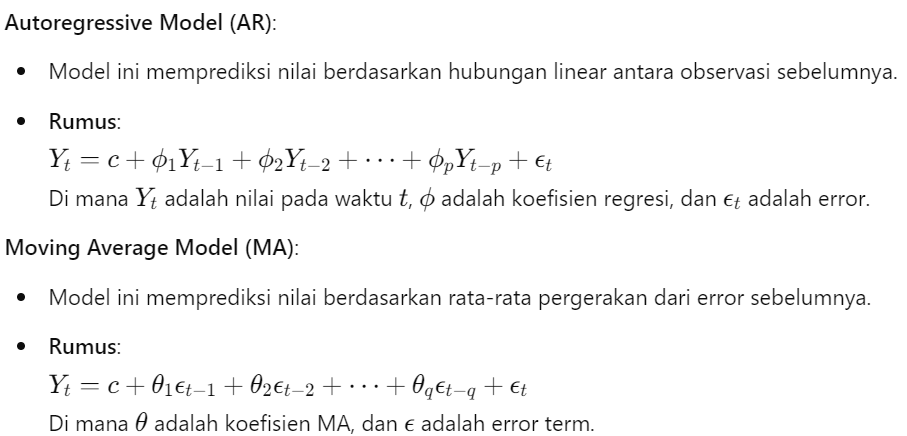

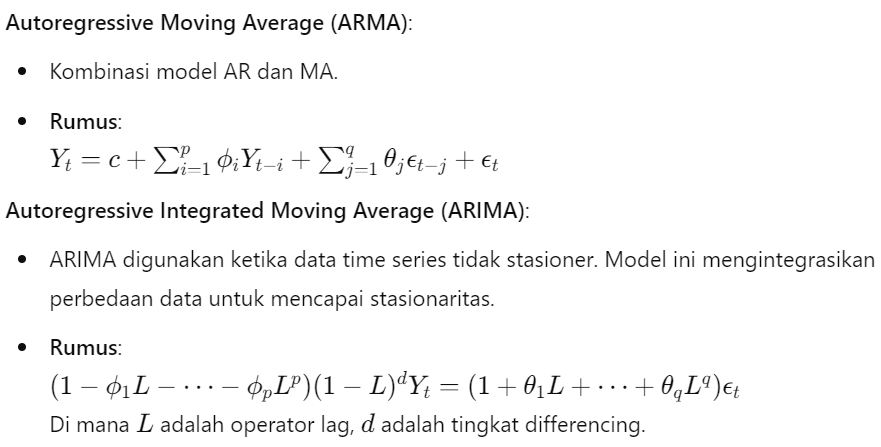

Berikut ini contoh penggunaan analisis ARIMA serta pengecekan asumsi stasionaritas dan autocorrelation.

1. Import Library

In [49]:
#pip install yfinance statsmodels matplotlib seaborn

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

2. Ambil data saham ketika di tutup

[*********************100%***********************]  1 of 1 completed

Price          Close
Ticker          NVDA
Date                
2020-01-02  5.970754
2020-01-03  5.875186
2020-01-06  5.899825
2020-01-07  5.971252
2020-01-08  5.982451


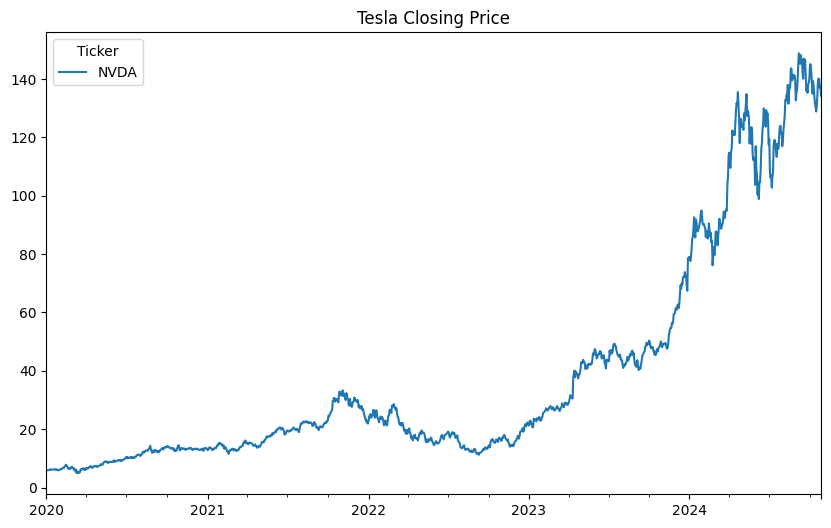

In [50]:
# Ambil data saham Tesla (TSLA)
data = yf.download('NVDA', start='2020-01-01', end='2025-01-01')
data = data[['Close']]  # Kita fokus pada harga penutupan
print(data.head())

# Set frekuensi pada indeks
data.index = pd.date_range(start='2020-01-01', periods=len(data), freq='B')  # B untuk hari kerja

# Visualisasi data harga penutupan
data['Close'].plot(figsize=(10,6), title='Tesla Closing Price')
plt.show()

In [51]:
# Cek apakah ada missing value
missing_values = data.isnull().sum()
print("Jumlah missing values per kolom:")
print(missing_values)


Jumlah missing values per kolom:
Price  Ticker
Close  NVDA      0
dtype: int64


In [52]:
# Cek apakah ada nilai NaN
nan_values = data.isna().sum()
print("Jumlah nilai NaN per kolom:")
print(nan_values)


Jumlah nilai NaN per kolom:
Price  Ticker
Close  NVDA      0
dtype: int64


3. Cek Asumsi Stasionaritas dengan Uji ADF (Augmented Dickey-Fuller Test)

In [53]:
from statsmodels.tsa.stattools import adfuller

# Uji ADF
result = adfuller(data['Close'])

print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])

# Cek Hipotesis
if result[1] < 0.05:
    print("Data stasioner, lanjutkan analisis.")
else:
    print("Data tidak stasioner, lakukan differencing.")


ADF Statistic: 0.913629
p-value: 0.993266
Data tidak stasioner, lakukan differencing.


4. Jika Data Tidak Stasioner, Lakukan Differencing

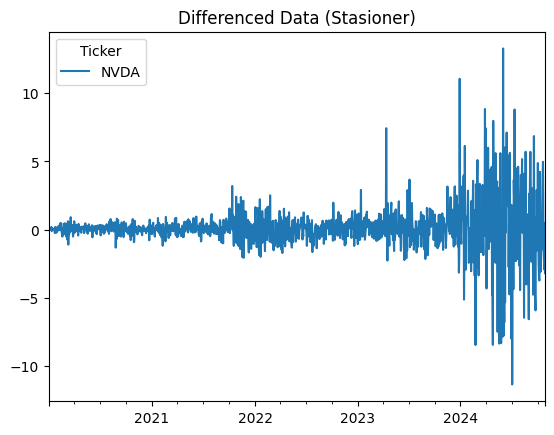

p-value after differencing: 0.000000
Data stasioner, lanjutkan analisis.


In [54]:
# Lakukan Differencing jika data tidak stasioner
data_diff = data['Close'].diff().dropna()
data_diff.plot(title="Differenced Data (Stasioner)")
plt.show()

# Uji ADF lagi setelah differencing
result_diff = adfuller(data_diff)
print('p-value after differencing: %f' % result_diff[1])

# Cek Hipotesis
if result_diff[1] < 0.05:
    print("Data stasioner, lanjutkan analisis.")
else:
    print("Data tidak stasioner, lakukan differencing.")


In [55]:
# Cek apakah ada missing value
missing_values = data_diff.isnull().sum()
print("Jumlah missing values per kolom:")
print(missing_values)

# Cek apakah ada nilai NaN
nan_values = data_diff.isna().sum()
print("Jumlah nilai NaN per kolom:")
print(nan_values)


Jumlah missing values per kolom:
Ticker
NVDA    0
dtype: int64
Jumlah nilai NaN per kolom:
Ticker
NVDA    0
dtype: int64


5. Cek Autocorrelation (ACF) dan Partial Autocorrelation (PACF)

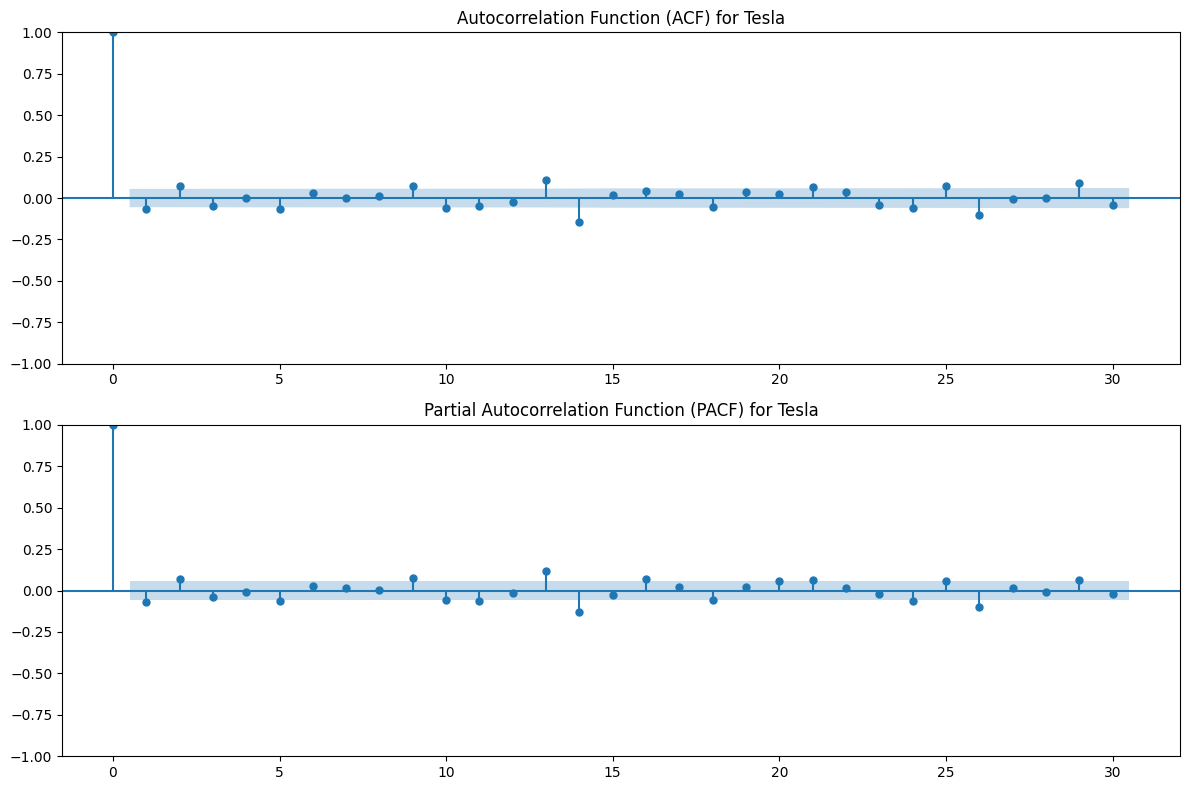

In [56]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Plot ACF dan PACF
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

# ACF untuk menentukan q
plot_acf(data_diff, lags=30, ax=ax[0])
ax[0].set_title('Autocorrelation Function (ACF) for Tesla')

# PACF untuk menentukan p
plot_pacf(data_diff, lags=30, ax=ax[1])
ax[1].set_title('Partial Autocorrelation Function (PACF) for Tesla')

plt.tight_layout()
plt.show()


ACF (Autocorrelation Function) dan PACF (Partial Autocorrelation Function) adalah dua alat penting dalam analisis time series, khususnya untuk memilih urutan dalam model ARIMA (AutoRegressive Integrated Moving Average).

ACF membantu dalam menentukan urutan MA (
𝑞) dari model ARIMA, yang menunjukkan korelasi antara nilai sekarang dan lag (nilai masa lalu).
PACF digunakan untuk menentukan urutan AR (
𝑝
) dari model ARIMA, yang menunjukkan korelasi antara nilai sekarang dan nilai masa lalu, dengan menghilangkan pengaruh lag perantara.
Secara umum:

AR (Autoregressive) 
𝑝
: Nilai 
𝑝
 adalah jumlah lag signifikan pertama pada PACF plot sebelum nilai PACF menurun secara cepat.
MA (Moving Average) 
𝑞
: Nilai 
𝑞
 adalah jumlah lag signifikan pertama pada ACF plot sebelum nilai ACF menurun secara cepat.

5. Membangun Model

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Membangun model ARIMA (p=1, d=1, q=1) berdasarkan plot ACF dan PACF
model = ARIMA(data, order=(1, 1, 1))
model_fit = model.fit()

# Tampilkan ringkasan model
print(model_fit.summary())



                               SARIMAX Results                                
Dep. Variable:             Close_NVDA   No. Observations:                 1258
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -2443.928
Date:                Mon, 30 Mar 2026   AIC                           4893.855
Time:                        14:06:07   BIC                           4909.265
Sample:                    01-01-2020   HQIC                          4899.647
                         - 10-25-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7121      0.069    -10.358      0.000      -0.847      -0.577
ma.L1          0.6402      0.076      8.376      0.000       0.490       0.790
sigma2         2.8594      0.046     62.070      0.0

Penilaian Model dilihat dari AIC dan atau BIC yang terkecil, ketika dibandingkan dengan model lain

6. Peramalan Data

In [58]:
# Jumlah langkah yang ingin diramalkan
n_steps = 2000000

# Lakukan peramalan
forecast = model_fit.forecast(steps=n_steps)

# Tampilkan hasil peramalan
print(forecast)


2024-10-28    134.598912
2024-10-29    134.347623
2024-10-30    134.526561
2024-10-31    134.399143
2024-11-01    134.489875
                 ...    
9690-12-11    134.452138
9690-12-12    134.452138
9690-12-13    134.452138
9690-12-14    134.452138
9690-12-15    134.452138
Freq: B, Name: predicted_mean, Length: 2000000, dtype: float64


In [59]:
# Visualisasi harga penutupan historis dan hasil peramalan
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Close'], label='Harga Penutupan Historis', color='blue')

# Membuat indeks untuk peramalan
forecast_index = pd.date_range(start=data.index[-1] + pd.Timedelta(days=1), periods=n_steps, freq='B')

# Plot hasil peramalan
plt.plot(forecast_index, forecast, label='Hasil Peramalan', color='orange', linestyle='--')

# Tambahkan elemen visual lainnya
plt.title('Peramalan Harga Penutupan Saham Tesla (TSLA)')
plt.xlabel('Tanggal')
plt.ylabel('Harga Penutupan')
plt.legend()
plt.grid()
plt.show()


ValueError: Date ordinal 2960108.95 converts to 10074-07-02T22:48:00.000032 (using epoch 1970-01-01T00:00:00), but Matplotlib dates must be between year 0001 and 9999.

<Figure size 1200x600 with 1 Axes>

---
# Analisis Time Series Multivariat

VAR (Vector Autoregression)

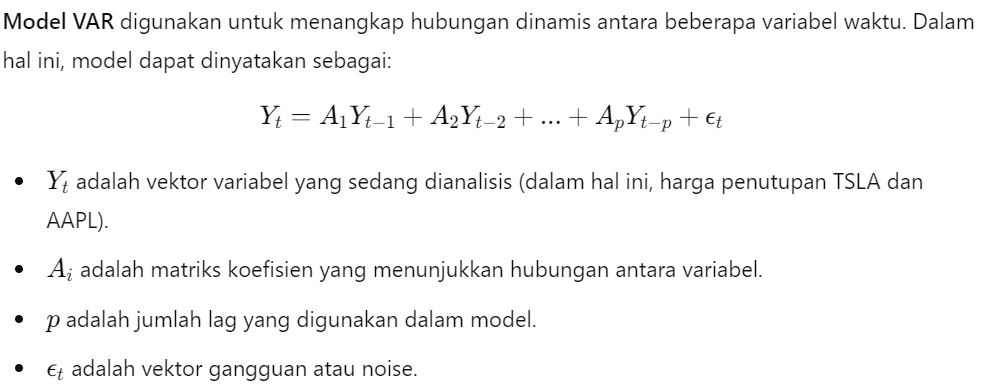

1. Import Data Tesla

[*********************100%***********************]  2 of 2 completed

                 TSLA       AAPL
2020-01-01  28.684000  72.400513
2020-01-02  29.534000  71.696632
2020-01-03  30.102667  72.267921
2020-01-06  31.270666  71.928055
2020-01-07  32.809334  73.085114
ADF Statistic: -1.8775284728871102
p-value: 0.342705134711416
Data tidak stasioner, lakukan differencing.
ADF Statistic: -1.8889081465071322
p-value: 0.33729692464950956
Data tidak stasioner, lakukan differencing.
Differencing dilakukan untuk TSLA.
Differencing dilakukan untuk AAPL.


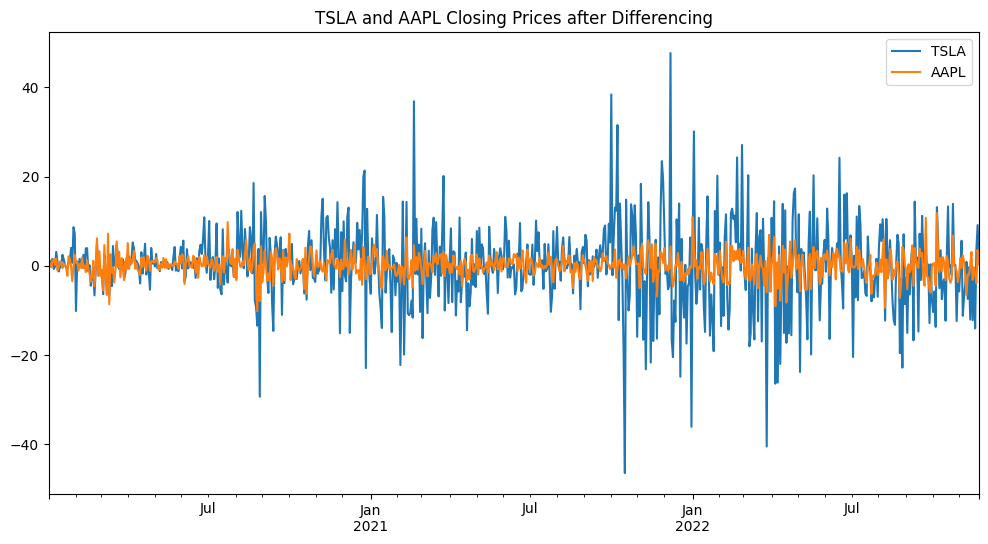

In [60]:
# Import libraries yang diperlukan
import yfinance as yf
import pandas as pd
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

# Ambil data harga penutupan untuk TSLA dan AAPL dengan frekuensi bisnis (B)
tickers = ['TSLA', 'AAPL']
data = yf.download(tickers, start='2020-01-01', end='2023-01-01', group_by='ticker')

# Set frekuensi pada indeks
data.index = pd.date_range(start='2020-01-01', periods=len(data), freq='B')  # B untuk hari kerja


# Ambil hanya harga penutupan
data_combined = pd.DataFrame({
    'TSLA': data['TSLA']['Close'],
    'AAPL': data['AAPL']['Close']
})

# Tampilkan beberapa baris data
print(data_combined.head())

# Fungsi untuk memeriksa stasionaritas
def check_stationarity(series):
    result = adfuller(series)
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    if result[1] < 0.05:
        print("Data stasioner, lanjutkan analisis.")
        return True
    else:
        print("Data tidak stasioner, lakukan differencing.")
        return False

# Cek stasionaritas untuk kedua variabel
is_stationary_tsla = check_stationarity(data_combined['TSLA'])
is_stationary_aapl = check_stationarity(data_combined['AAPL'])

# Lakukan differencing jika diperlukan
if not is_stationary_tsla:
    data_combined['TSLA'] = data_combined['TSLA'].diff().dropna()
    print("Differencing dilakukan untuk TSLA.")

if not is_stationary_aapl:
    data_combined['AAPL'] = data_combined['AAPL'].diff().dropna()
    print("Differencing dilakukan untuk AAPL.")

# Hapus NaN yang mungkin ada setelah differencing
data_combined = data_combined.dropna()

# Visualisasikan data yang telah di-differencing
data_combined.plot(figsize=(12, 6), title='TSLA and AAPL Closing Prices after Differencing')
plt.show()


In [61]:
from statsmodels.tsa.api import VAR

# Langkah 1: Tentukan lag optimal
model = VAR(data_combined)
lag_order = model.select_order(maxlags=15)  # Menentukan lag optimal hingga 15 lag
print(lag_order.summary())

# Langkah 2: Buat model berdasarkan lag optimal
optimal_lag = lag_order.aic  # Menggunakan AIC untuk lag optimal
var_model = model.fit(optimal_lag)

# Langkah 3: Tampilkan ringkasan model
print(var_model.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       6.122*      6.135*      455.9*      6.127*
1        6.128       6.166       458.7       6.143
2        6.134       6.196       461.3       6.158
3        6.143       6.230       465.4       6.176
4        6.148       6.260       467.6       6.191
5        6.154       6.291       470.7       6.207
6        6.163       6.324       474.6       6.225
7        6.162       6.349       474.3       6.234
8        6.162       6.374       474.4       6.244
9        6.164       6.400       475.2       6.255
10       6.169       6.430       477.6       6.270
11       6.167       6.454       476.9       6.278
12       6.174       6.485       479.9       6.294
13       6.180       6.516       483.1       6.310
14       6.185       6.547       485.7       6.325
15       6.186       6.572       485.9       6.335
-------------------------------